# Comparison of Two Time Series of Maps 0.1

*This streamlined notebook focuses on the statistical summaries and charts. Provide your inputs in the first cells, run the calculations, and then generate the figures directly from the CSV files exported by the workflow.*

## Notebook Workflow

1. **Set inputs** – Update paths, time points, and flags in the next code cell.
2. **Load libraries** – Run the import cell to ensure all packages are available.
3. **Initialize helpers** – Execute the helper-functions cell (no edits required).
4. **Run calculations** – Execute the metric calculations and CSV export cells.
5. **Produce charts** – Generate the presence, gross-change, and net-change figures.
6. **Create rasters** – Run the raster generation cell; progress bars show status.
7. **Export maps** – Execute the final visualization cell to save PNG maps.

## 1. Environment Setup

In [1]:
# =============================================================================
# 1. Load the libraries
# =============================================================================
from pathlib import Path

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from tqdm.auto import tqdm

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow
from pyproj import CRS, Transformer

mpl.rcParams["font.family"] = "serif"


### 1.1 Provide file paths and analysis parameters

*Edit the next cell so it matches your folders, time points, and NoData value before running the rest of the notebook.*

In [2]:
# =============================================================================
# 1. Define the analysis inputs (edit this cell)
# =============================================================================
# Provide the folders containing the raster time series for X (reference) and Y (comparison).
path_series_x = Path(
    "C:/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/pixelbased"
)
path_series_y = Path(
    "C:/Users/AntFonseca/github/1.INPUT/compare-time-series/PIE/objectbased"
)

# List the time points (years) to analyze.
time_points = [
    2010,
    2012,
    2014,
    2016,
    2018,
    2021
]

# Set a short class name used in output filenames.
class_name = "PIE"

# Indicate whether the rasters contain binary (0/1) data.
is_binary_data = True

# Specify the NoData value stored in the rasters.
nodata_value = 255

# Choose where all outputs (CSV, GeoTIFF, PNG) will be saved.
output_path = Path(
    f"C:/Users/AntFonseca/github/2.OUTPUT/{class_name}"
)
output_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Parameters successfully defined.")


Parameters successfully defined.


## 2. Helper Functions

In [3]:
# =============================================================================
# 2. Helper functions (no need to edit)
# =============================================================================
"""Utilities shared by the calculations, raster generation, and plotting."""

raster_arrays = {}
MAP_SCALE_FACTOR = 0.15
_reference_profile_cache = None


def get_raster_array(year):
    """Return the X and Y rasters for *year*, caching the result."""
    if year in raster_arrays:
        return raster_arrays[year]

    file_name = f"{class_name}{year}.tif"
    path_x = path_series_x / file_name
    path_y = path_series_y / file_name

    if not path_x.exists() or not path_y.exists():
        print(f"Warning: file '{file_name}' not found for year {year}.")
        return None, None

    with rasterio.open(path_x) as src_x:
        array_x = src_x.read(1)
    with rasterio.open(path_y) as src_y:
        array_y = src_y.read(1)

    raster_arrays[year] = (array_x, array_y)
    return array_x, array_y


def calculate_presence_metrics(path_x, path_y):
    """Return presence agreement metrics for a single year."""
    with rasterio.open(path_x) as src_x:
        array_x = src_x.read(1)
    with rasterio.open(path_y) as src_y:
        array_y = src_y.read(1)

    valid_mask = (
        (array_x != nodata_value)
        & (array_y != nodata_value)
    )

    presence_x = array_x[valid_mask]
    presence_y = array_y[valid_mask]

    hits = np.minimum(presence_x, presence_y).sum(dtype=np.int64)
    total_x = presence_x.sum(dtype=np.int64)
    total_y = presence_y.sum(dtype=np.int64)

    space_difference = (
        np.minimum(total_x, total_y)
        - hits
    )
    misses = np.maximum(0, total_x - total_y)
    false_alarms = np.maximum(0, total_y - total_x)

    return {
        "Hit": int(hits),
        "Miss": int(misses),
        "False Alarm": int(false_alarms),
        "Space Difference": int(space_difference),
        "Total X": int(total_x),
        "Total Y": int(total_y),
    }


def calculate_change_metrics(year_t, year_t_minus_1):
    """Return gross change metrics for the interval (t-1, t)."""
    array_x_t, array_y_t = get_raster_array(year_t)
    array_x_prev, array_y_prev = get_raster_array(year_t_minus_1)

    if array_x_t is None or array_x_prev is None:
        return None

    change_x = np.subtract(array_x_t, array_x_prev, dtype=np.int16)
    change_y = np.subtract(array_y_t, array_y_prev, dtype=np.int16)

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)

    gain_total_x = int(gain_x.sum())
    gain_total_y = int(gain_y.sum())
    loss_total_x = int(loss_x.sum())
    loss_total_y = int(loss_y.sum())

    gain_hit = int(np.minimum(gain_x, gain_y).sum())
    gain_space_difference = (
        min(gain_total_x, gain_total_y)
        - gain_hit
    )
    gain_miss = max(0, gain_total_x - gain_total_y)
    gain_false_alarm = max(0, gain_total_y - gain_total_x)

    loss_hit = int(np.maximum(loss_x, loss_y).sum())
    loss_space_difference = (
        max(loss_total_x, loss_total_y)
        - loss_hit
    )
    loss_miss = min(0, loss_total_x - loss_total_y)
    loss_false_alarm = min(0, loss_total_y - loss_total_x)

    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_difference,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_difference,
        "Gain Total X": gain_total_x,
        "Gain Total Y": gain_total_y,
        "Loss Total X": loss_total_x,
        "Loss Total Y": loss_total_y,
    }


def calculate_extent_metrics(time_points_list):
    """Return gross change metrics for the full temporal extent."""
    start_year = time_points_list[0]
    end_year = time_points_list[-1]

    array_x_start, array_y_start = get_raster_array(start_year)
    array_x_end, array_y_end = get_raster_array(end_year)

    if array_x_start is None or array_x_end is None:
        return None

    change_x = np.subtract(array_x_end, array_x_start, dtype=np.int16)
    change_y = np.subtract(array_y_end, array_y_start, dtype=np.int16)

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)

    gain_total_x = int(gain_x.sum())
    gain_total_y = int(gain_y.sum())
    loss_total_x = int(loss_x.sum())
    loss_total_y = int(loss_y.sum())

    gain_hit = int(np.minimum(gain_x, gain_y).sum())
    gain_space_difference = (
        min(gain_total_x, gain_total_y)
        - gain_hit
    )
    gain_miss = max(0, gain_total_x - gain_total_y)
    gain_false_alarm = max(0, gain_total_y - gain_total_x)

    loss_hit = int(np.maximum(loss_x, loss_y).sum())
    loss_space_difference = (
        max(loss_total_x, loss_total_y)
        - loss_hit
    )
    loss_miss = min(0, loss_total_x - loss_total_y)
    loss_false_alarm = min(0, loss_total_y - loss_total_x)

    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_difference,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_difference,
    }


def calculate_net_change_components(gross_results):
    """Convert gross change metrics to net change components."""
    if gross_results is None:
        return None

    gain_hits = gross_results.get("Gain Hits", 0)
    gain_space = gross_results.get("Gain Space Difference", 0)
    gain_miss = gross_results.get("Gain Miss", 0)
    gain_false = gross_results.get("Gain False Alarm", 0)
    loss_hits = gross_results.get("Loss Hits", 0)
    loss_space = gross_results.get("Loss Space Difference", 0)
    loss_miss = gross_results.get("Loss Miss", 0)
    loss_false = gross_results.get("Loss False Alarm", 0)

    quantity_gain_x = max(
        0,
        gain_hits + gain_space + gain_miss + loss_hits + loss_space + loss_miss
    )
    quantity_gain_y = max(
        0,
        gain_hits + gain_space + gain_false + loss_hits + loss_space + loss_false
    )
    quantity_loss_x = min(
        0,
        gain_hits + gain_space + gain_miss + loss_hits + loss_space + loss_miss
    )
    quantity_loss_y = min(
        0,
        gain_hits + gain_space + gain_false + loss_hits + loss_space + loss_false
    )

    net_gain_hits = min(quantity_gain_x, quantity_gain_y)
    net_gain_miss = max(0, quantity_gain_x - quantity_gain_y)
    net_gain_false = max(0, quantity_gain_y - quantity_gain_x)

    net_loss_hits = max(quantity_loss_x, quantity_loss_y)
    net_loss_miss = min(0, quantity_loss_x - quantity_loss_y)
    net_loss_false = min(0, quantity_loss_y - quantity_loss_x)

    return {
        "Gain Hits": int(net_gain_hits),
        "Gain Miss": int(net_gain_miss),
        "Gain False Alarm": int(net_gain_false),
        "Loss Hits": int(net_loss_hits),
        "Loss Miss": int(net_loss_miss),
        "Loss False Alarm": int(net_loss_false),
        "QG_Total_X": int(quantity_gain_x),
        "QG_Total_Y": int(quantity_gain_y),
        "QL_Total_X": int(quantity_loss_x),
        "QL_Total_Y": int(quantity_loss_y),
    }


def ensure_reference_profile():
    """Return the reference raster profile and dimensions."""
    global _reference_profile_cache

    if _reference_profile_cache is not None:
        return _reference_profile_cache

    first_year = time_points[0]
    file_name = f"{class_name}{first_year}.tif"
    reference_path = path_series_x / file_name

    if not reference_path.exists():
        raise FileNotFoundError(
            f"Reference file not found: {reference_path}"
        )

    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
        height = src.height
        width = src.width

    _reference_profile_cache = (profile, height, width)
    return _reference_profile_cache


def decimal_to_dms(value):
    """Convert decimal degrees to degrees, minutes, and seconds."""
    degrees = int(abs(value))
    minutes_float = (abs(value) - degrees) * 60.0
    minutes = int(minutes_float)
    seconds = (minutes_float - minutes) * 60.0
    return degrees, minutes, seconds


def make_lon_formatter(transformer, bounds):
    """Create a formatter for longitude tick labels."""

    def _formatter(x_value, _):
        lon, _ = transformer.transform(x_value, bounds.bottom)
        degrees, minutes, seconds = decimal_to_dms(lon)
        suffix = "E" if lon >= 0 else "W"
        return (
            f"{degrees}° "
            f"{minutes}' "
            f"{seconds:.2f}\""
            f"{suffix}"
        )

    return FuncFormatter(_formatter)


def make_lat_formatter(transformer, bounds):
    """Create a formatter for latitude tick labels."""

    def _formatter(y_value, _):
        _, lat = transformer.transform(bounds.left, y_value)
        degrees, minutes, seconds = decimal_to_dms(lat)
        suffix = "N" if lat >= 0 else "S"
        return (
            f"{degrees}° "
            f"{minutes}' "
            f"{seconds:.2f}\""
            f"{suffix}"
        )

    return FuncFormatter(_formatter)


def add_scalebar(ax, bounds, src_crs, transformer, length_fraction=0.4):
    """Add a consistent scale bar to the provided axes."""
    crs_obj = CRS.from_user_input(src_crs)

    if crs_obj.is_geographic:
        center_x = (bounds.left + bounds.right) / 2.0
        center_y = (bounds.bottom + bounds.top) / 2.0
        lon_center, lat_center = transformer.transform(center_x, center_y)
        meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat_center))
        dx_km = meters_per_degree_lon / 1000.0
    else:
        try:
            meters_per_unit = crs_obj.axis_info[0].unit_conversion_factor
        except Exception:
            meters_per_unit = 1.0
        dx_km = meters_per_unit / 1000.0

    scalebar = ScaleBar(
        dx_km,
        units="km",
        length_fraction=length_fraction,
        location="lower right"
    )
    ax.add_artist(scalebar)


def prepare_map_axes(ax, bounds, src_crs, transformer):
    """Apply shared axis formatting, north arrow, and scale bar."""
    ax.xaxis.set_major_formatter(make_lon_formatter(transformer, bounds))
    ax.yaxis.set_major_formatter(make_lat_formatter(transformer, bounds))
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
    ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")
    north_arrow(ax, location="upper right", rotation={"degrees": 0}, shadow=False)
    add_scalebar(ax, bounds, src_crs, transformer)
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)


def read_resampled_map(raster_path, scale_factor=MAP_SCALE_FACTOR):
    """Read a raster and resample it for plotting."""
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        src_crs = src.crs
        transformer = Transformer.from_crs(
            src_crs,
            "EPSG:4326",
            always_xy=True
        )
        data = src.read(
            1,
            out_shape=(
                int(src.height * scale_factor),
                int(src.width * scale_factor)
            ),
            resampling=Resampling.nearest
        )

    masked = np.ma.masked_equal(data, nodata_value)
    return masked, bounds, src_crs, transformer


def blue_gray_red_cmap():
    """Return the diverging colormap used in change-difference plots."""
    return mcolors.LinearSegmentedColormap.from_list(
        "red_gray_blue",
        [
            "#a50026",
            "#f46d43",
            "#f2f2f2",
            "#74add1",
            "#313695"
        ]
    )


print("All calculation functions are defined.")


All calculation functions are defined.


## 3. Run Calculations

In [4]:
# =============================================================================
# 3. Run all calculations
# =============================================================================
print("Starting all data processing and calculations...")

# -----------------------------------------------------------------------------
# 3.1 Presence metrics
# -----------------------------------------------------------------------------
results_by_time = {}
for year in time_points:
    file_name = f"{class_name}{year}.tif"
    path_x = path_series_x / file_name
    path_y = path_series_y / file_name

    if not path_x.exists() or not path_y.exists():
        print(f"Skipping year {year}: file '{file_name}' not found.")
        continue

    results_by_time[year] = calculate_presence_metrics(
        path_x,
        path_y
    )

sum_results = {
    "Hit": 0,
    "Space Difference": 0,
    "Miss": 0,
    "False Alarm": 0,
    "Total X": 0,
    "Total Y": 0,
}

for metrics in results_by_time.values():
    sum_results["Hit"] += metrics["Hit"]
    sum_results["Space Difference"] += metrics["Space Difference"]
    sum_results["Miss"] += metrics["Miss"]
    sum_results["False Alarm"] += metrics["False Alarm"]
    sum_results["Total X"] += metrics["Total X"]
    sum_results["Total Y"] += metrics["Total Y"]

sum_results["Time Difference"] = (
    min(
        sum_results["Total X"],
        sum_results["Total Y"]
    )
    - sum_results["Hit"]
    - sum_results["Space Difference"]
)

print("Presence metrics ready.")

# -----------------------------------------------------------------------------
# 3.2 Gross change metrics
# -----------------------------------------------------------------------------
change_results_by_interval = {}
time_intervals = []

for index in range(1, len(time_points)):
    year_t = time_points[index]
    year_prev = time_points[index - 1]
    interval_label = f"{year_prev}-{year_t}"
    time_intervals.append(interval_label)

    gross_metrics = calculate_change_metrics(
        year_t,
        year_prev
    )
    if gross_metrics is not None:
        change_results_by_interval[interval_label] = gross_metrics
    else:
        print(f"Skipping interval {interval_label}: missing rasters.")

extent_results = calculate_extent_metrics(time_points)

sum_change_results = {
    "Gain Hits": 0,
    "Gain Space Difference": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Gain Total X": 0,
    "Gain Total Y": 0,
    "Loss Hits": 0,
    "Loss Space Difference": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
    "Loss Total X": 0,
    "Loss Total Y": 0,
}

for metrics in change_results_by_interval.values():
    sum_change_results["Gain Hits"] += metrics["Gain Hits"]
    sum_change_results["Gain Space Difference"] += metrics["Gain Space Difference"]
    sum_change_results["Gain Miss"] += metrics["Gain Miss"]
    sum_change_results["Gain False Alarm"] += metrics["Gain False Alarm"]
    sum_change_results["Gain Total X"] += metrics["Gain Total X"]
    sum_change_results["Gain Total Y"] += metrics["Gain Total Y"]
    sum_change_results["Loss Hits"] += metrics["Loss Hits"]
    sum_change_results["Loss Space Difference"] += metrics["Loss Space Difference"]
    sum_change_results["Loss Miss"] += metrics["Loss Miss"]
    sum_change_results["Loss False Alarm"] += metrics["Loss False Alarm"]
    sum_change_results["Loss Total X"] += metrics["Loss Total X"]
    sum_change_results["Loss Total Y"] += metrics["Loss Total Y"]

sum_change_results["Gain Time Difference"] = (
    min(
        sum_change_results["Gain Total X"],
        sum_change_results["Gain Total Y"]
    )
    - sum_change_results["Gain Hits"]
    - sum_change_results["Gain Space Difference"]
)

sum_change_results["Loss Time Difference"] = (
    max(
        sum_change_results["Loss Total X"],
        sum_change_results["Loss Total Y"]
    )
    - sum_change_results["Loss Hits"]
    - sum_change_results["Loss Space Difference"]
)

print("Gross change metrics ready.")

# -----------------------------------------------------------------------------
# 3.3 Net change metrics
# -----------------------------------------------------------------------------
net_change_by_interval = {}
for interval_label, gross_metrics in change_results_by_interval.items():
    net_metrics = calculate_net_change_components(gross_metrics)
    if net_metrics is not None:
        net_change_by_interval[interval_label] = net_metrics

net_extent_results = calculate_net_change_components(extent_results)

sum_net_results = {
    "Gain Hits": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Gain Time Difference": 0,
    "Loss Hits": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
    "Loss Time Difference": 0,
    "QG_Total_X": 0,
    "QG_Total_Y": 0,
    "QL_Total_X": 0,
    "QL_Total_Y": 0,
}

for metrics in net_change_by_interval.values():
    sum_net_results["Gain Hits"] += metrics["Gain Hits"]
    sum_net_results["Gain Miss"] += metrics["Gain Miss"]
    sum_net_results["Gain False Alarm"] += metrics["Gain False Alarm"]
    sum_net_results["Loss Hits"] += metrics["Loss Hits"]
    sum_net_results["Loss Miss"] += metrics["Loss Miss"]
    sum_net_results["Loss False Alarm"] += metrics["Loss False Alarm"]
    sum_net_results["QG_Total_X"] += metrics["QG_Total_X"]
    sum_net_results["QG_Total_Y"] += metrics["QG_Total_Y"]
    sum_net_results["QL_Total_X"] += metrics["QL_Total_X"]
    sum_net_results["QL_Total_Y"] += metrics["QL_Total_Y"]

sum_net_results["Gain Time Difference"] = (
    min(
        sum_net_results["QG_Total_X"],
        sum_net_results["QG_Total_Y"]
    )
    - sum_net_results["Gain Hits"]
)

sum_net_results["Loss Time Difference"] = (
    max(
        sum_net_results["QL_Total_X"],
        sum_net_results["QL_Total_Y"]
    )
    - sum_net_results["Loss Hits"]
)

print("Net change metrics ready.")
print("\n? All calculations are complete.")

Starting all data processing and calculations...
Presence metrics ready.
Gross change metrics ready.
Net change metrics ready.

? All calculations are complete.


## 4. Export Statistics to CSV

In [5]:
# =============================================================================
# 4. Export the statistics to CSV files
# =============================================================================
print("Exporting summary tables to CSV...")

# -----------------------------------------------------------------------------
# 4.1 Presence agreement
# -----------------------------------------------------------------------------
presence_rows = []
for tp in time_points:
    row = results_by_time.get(tp, {}).copy()
    row["Time Point"] = tp
    presence_rows.append(row)

sum_row_presence = sum_results.copy()
sum_row_presence["Time Point"] = "Sum"
presence_rows.append(sum_row_presence)

df_presence = pd.DataFrame(presence_rows)
presence_columns = [
    "Time Point",
    "Hit",
    "Space Difference",
    "Time Difference",
    "Miss",
    "False Alarm",
    "Total X",
    "Total Y",
]
df_presence = (
    df_presence[presence_columns]
    .fillna(0)
)

presence_csv_path = output_path / f"presence_agreement_{class_name}.csv"
df_presence.to_csv(
    presence_csv_path,
    index=False
)

# -----------------------------------------------------------------------------
# 4.2 Gross change
# -----------------------------------------------------------------------------
gross_rows = []
for interval in time_intervals:
    row = change_results_by_interval.get(interval, {}).copy()
    row["Interval"] = interval
    gross_rows.append(row)

sum_row_gross = sum_change_results.copy()
sum_row_gross["Interval"] = "Sum"
gross_rows.append(sum_row_gross)

extent_row_gross = (extent_results or {}).copy()
extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
gross_rows.append(extent_row_gross)

df_gross = pd.DataFrame(gross_rows)
gross_columns = [
    "Interval",
    "Gain Hits",
    "Gain Space Difference",
    "Gain Time Difference",
    "Gain Miss",
    "Gain False Alarm",
    "Loss Hits",
    "Loss Space Difference",
    "Loss Time Difference",
    "Loss Miss",
    "Loss False Alarm",
]
df_gross = (
    df_gross[gross_columns]
    .fillna(0)
)

gross_csv_path = output_path / f"gross_change_{class_name}.csv"
df_gross.to_csv(
    gross_csv_path,
    index=False
)

# -----------------------------------------------------------------------------
# 4.3 Net change
# -----------------------------------------------------------------------------
net_rows = []
for interval in time_intervals:
    row = net_change_by_interval.get(interval, {}).copy()
    row["Interval"] = interval
    net_rows.append(row)

sum_row_net = sum_net_results.copy()
sum_row_net["Interval"] = "Sum"
net_rows.append(sum_row_net)

extent_row_net = (net_extent_results or {}).copy()
extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
net_rows.append(extent_row_net)

df_net = pd.DataFrame(net_rows)
net_columns = [
    "Interval",
    "Gain Hits",
    "Gain Time Difference",
    "Gain Miss",
    "Gain False Alarm",
    "Loss Hits",
    "Loss Time Difference",
    "Loss Miss",
    "Loss False Alarm",
]
df_net = (
    df_net[net_columns]
    .fillna(0)
)

net_csv_path = output_path / f"net_change_{class_name}.csv"
df_net.to_csv(
    net_csv_path,
    index=False
)

print("CSV files saved:")
print(f" - {presence_csv_path}")
print(f" - {gross_csv_path}")
print(f" - {net_csv_path}")

Exporting summary tables to CSV...
CSV files saved:
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\presence_agreement_PIE.csv
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\gross_change_PIE.csv
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\net_change_PIE.csv


## 5. Load Statistics from CSV for Plotting

In [6]:
# =============================================================================
# 5. Load the CSV files for plotting
# =============================================================================
presence_csv_path = output_path / f"presence_agreement_{class_name}.csv"
gross_csv_path = output_path / f"gross_change_{class_name}.csv"
net_csv_path = output_path / f"net_change_{class_name}.csv"

presence_df = pd.read_csv(
    presence_csv_path,
    dtype={"Time Point": str}
).fillna(0)

gross_df = pd.read_csv(
    gross_csv_path,
    dtype={"Interval": str}
).fillna(0)

net_df = pd.read_csv(
    net_csv_path,
    dtype={"Interval": str}
).fillna(0)

print("CSV files loaded for plotting.")
print(f" - {presence_csv_path}")
print(f" - {gross_csv_path}")
print(f" - {net_csv_path}")

CSV files loaded for plotting.
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\presence_agreement_PIE.csv
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\gross_change_PIE.csv
 - C:\Users\AntFonseca\github\2.OUTPUT\PIE\net_change_PIE.csv


## 6. Plot Presence Agreement

### 6.1 Time Points


Building the presence agreement chart (time points)...


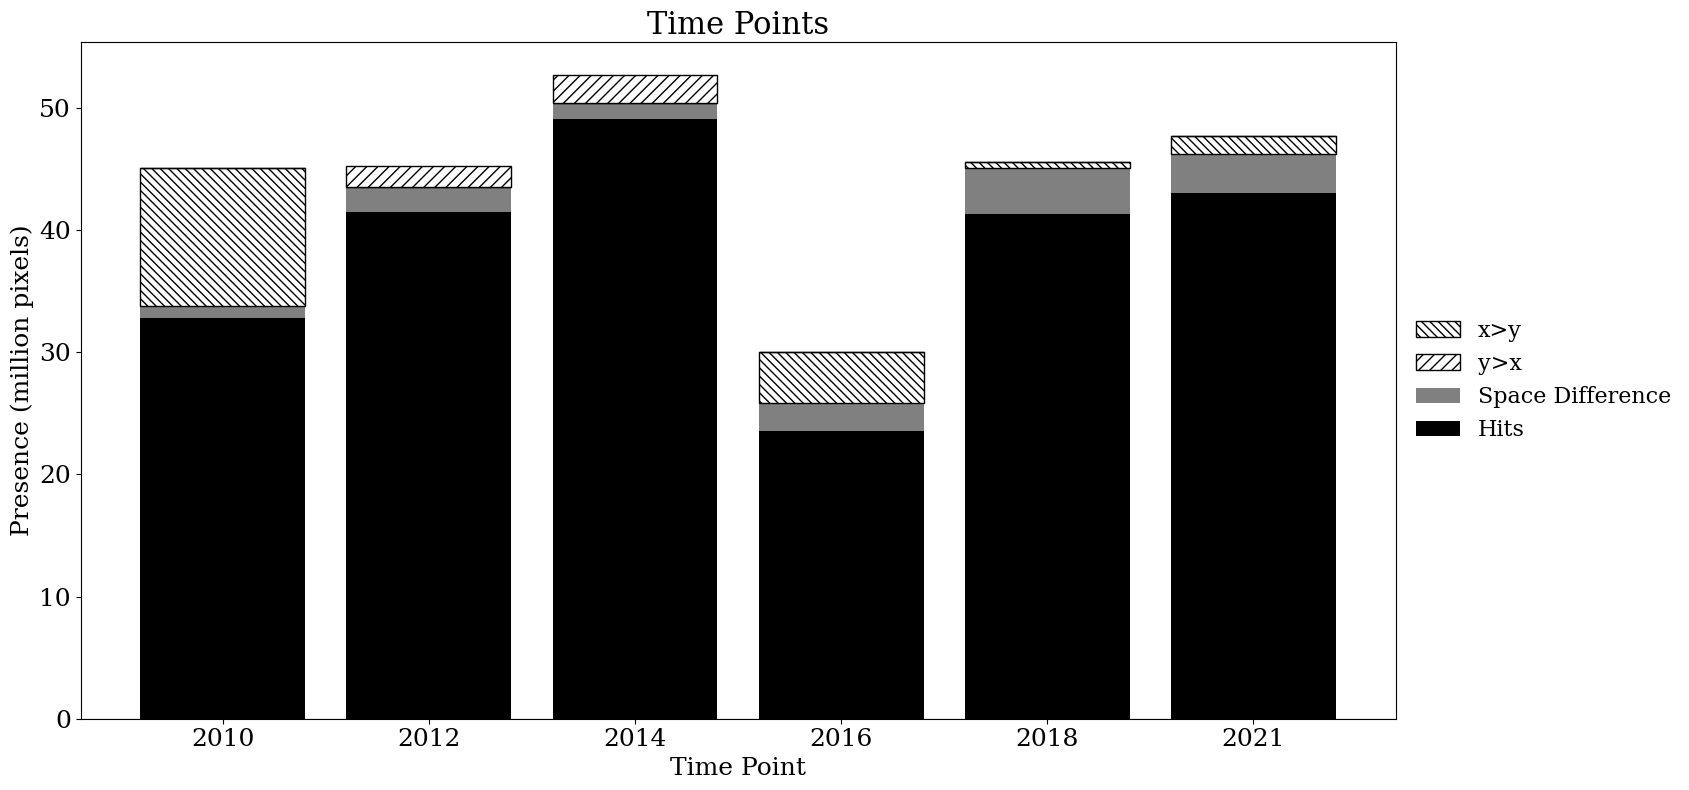

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\presence_agreement_PIE.png


In [7]:
# =============================================================================
# 6.1 Plot presence agreement across time points
# =============================================================================
print("\nBuilding the presence agreement chart (time points)...")

mpl.rcParams["font.family"] = "serif"

presence_time_df = (
    presence_df[presence_df["Time Point"] != "Sum"]
    .copy()
    .fillna(0)
)

presence_time_df["Time Point Numeric"] = pd.to_numeric(
    presence_time_df["Time Point"],
    errors="coerce"
)
presence_time_df = presence_time_df.sort_values(
    by="Time Point Numeric"
)

labels = presence_time_df["Time Point"].astype(str).tolist()

hits = presence_time_df["Hit"].to_numpy()
space_diff = presence_time_df["Space Difference"].to_numpy()
time_diff = presence_time_df["Time Difference"].to_numpy()
misses = presence_time_df["Miss"].to_numpy()
false_alarms = presence_time_df["False Alarm"].to_numpy()

fig, ax = plt.subplots(
    figsize=(20, 8)
)

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.bar(
    labels,
    hits,
    label="Hits",
    color="black",
    bottom=bottom
)
bottom += hits

ax.bar(
    labels,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom
)
bottom += space_diff

ax.bar(
    labels,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom
)
bottom += time_diff

ax.bar(
    labels,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\\\",
    bottom=bottom
)
bottom += misses

ax.bar(
    labels,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom
)

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

order = [
    "x>y",
    "y>x",
    "Space Difference",
    "Hits",
]

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

ax.set_title(
    "Time Points",
    fontsize=22
)
ax.set_xlabel(
    "Time Point",
    fontsize=18
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)

def millions_formatter(y_value, _):
    return f"{y_value / 1_000_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)
ax.set_ylabel(
    "Presence (million pixels)",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 0.85, 1]
)

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300
)
plt.show()

print(f"Chart saved to: {final_chart_path}")

### 6.2 Sum


Building the presence agreement chart (sum)...


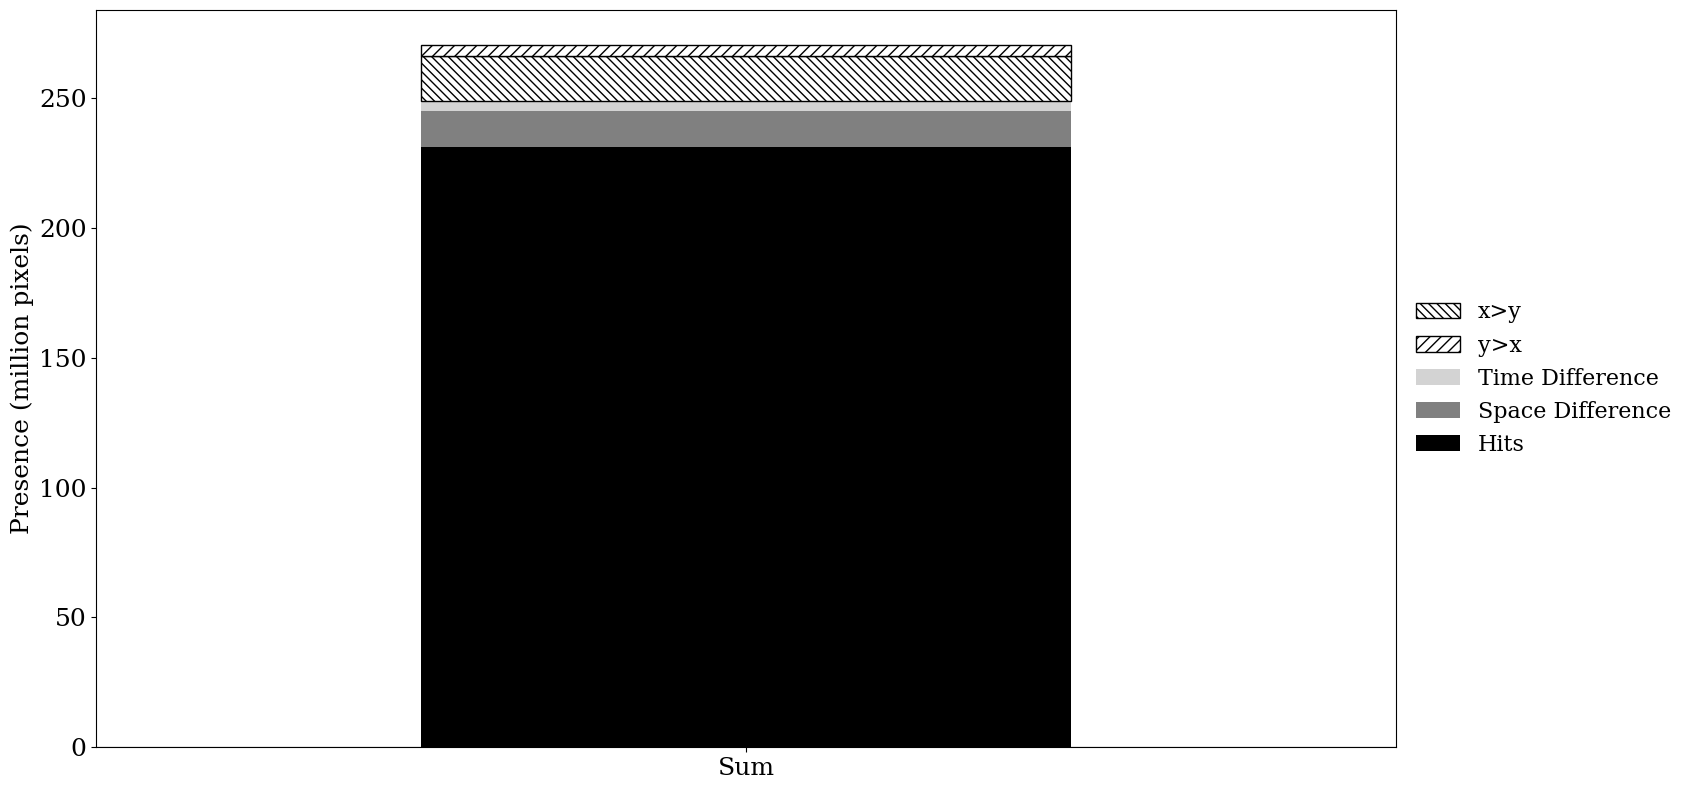

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\presence_agreement_PIE.png


In [8]:
# =============================================================================
# 6.2 Plot the presence agreement sum
# =============================================================================
print("\nBuilding the presence agreement chart (sum)...")

mpl.rcParams["font.family"] = "serif"

presence_sum_row = presence_df[presence_df["Time Point"] == "Sum"].fillna(0)
if presence_sum_row.empty:
    raise ValueError("The presence CSV does not contain the 'Sum' row.")

hits = presence_sum_row["Hit"].to_numpy()
space_diff = presence_sum_row["Space Difference"].to_numpy()
time_diff = presence_sum_row["Time Difference"].to_numpy()
misses = presence_sum_row["Miss"].to_numpy()
false_alarms = presence_sum_row["False Alarm"].to_numpy()

fig, ax = plt.subplots(
    figsize=(20, 8)
)

positions = np.array([0])
bottom = np.zeros(len(positions))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

bar_width = 0.2

ax.bar(
    positions,
    hits,
    label="Hits",
    color="black",
    bottom=bottom,
    width=bar_width
)
bottom += hits

ax.bar(
    positions,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom,
    width=bar_width
)
bottom += space_diff

ax.bar(
    positions,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom,
    width=bar_width
)
bottom += time_diff

ax.bar(
    positions,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\\\",
    bottom=bottom,
    width=bar_width
)
bottom += misses

ax.bar(
    positions,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom,
    width=bar_width
)

ax.set_xticks(
    positions
)
ax.set_xticklabels(
    ["Sum"]
)
ax.set_xlim(
    -0.2,
    0.2
)

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

order = [
    "x>y",
    "y>x",
    "Time Difference",
    "Space Difference",
    "Hits",
]

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)

def millions_formatter(y_value, _):
    return f"{y_value / 1_000_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)
ax.set_ylabel(
    "Presence (million pixels)",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 0.85, 1]
)

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300
)
plt.show()

print(f"Chart saved to: {final_chart_path}")

## 7. Plot Gross Change

### 7.1 Time Intervals


Building the gross change chart (intervals)...


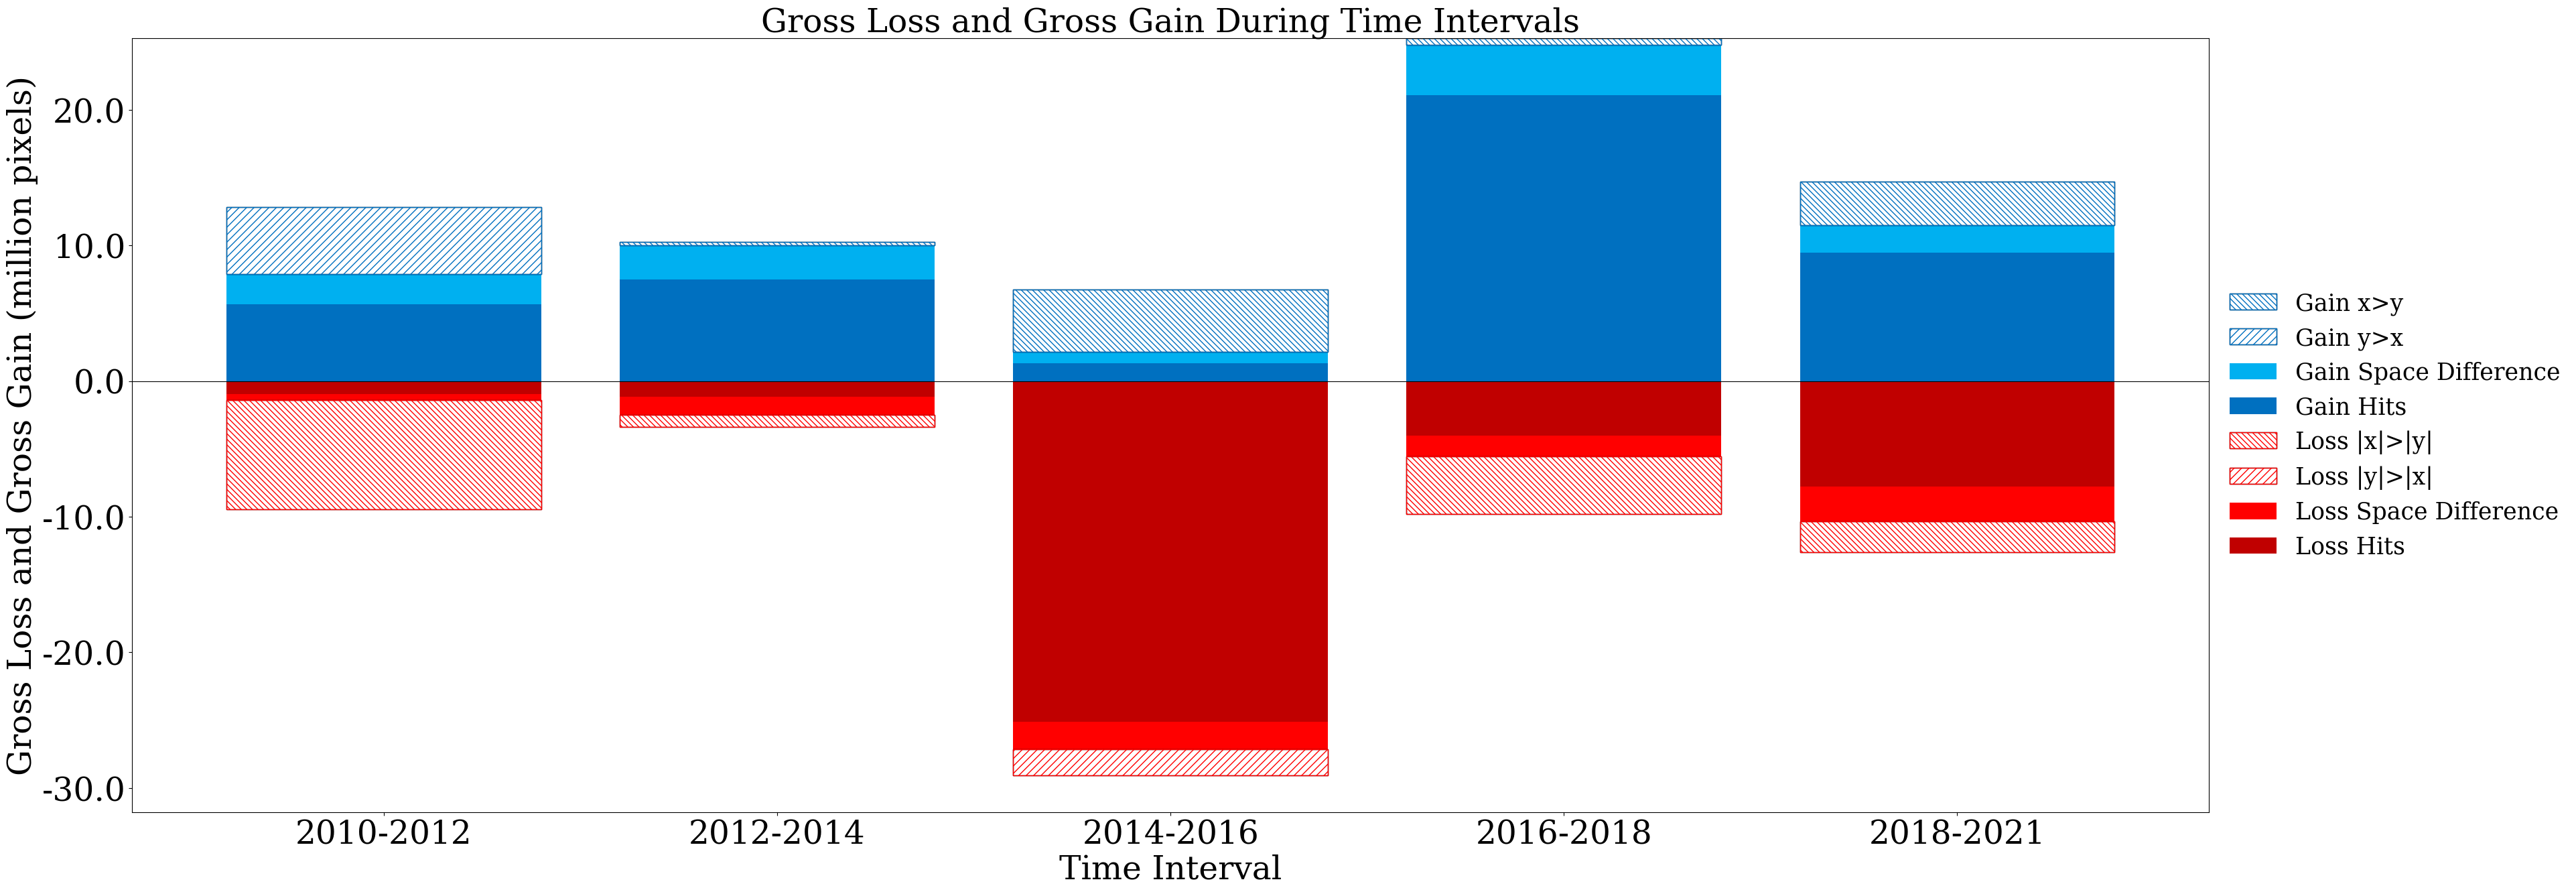

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\gross_change_PIE.png


In [9]:
# =============================================================================
# 7.1 Plot gross change across time intervals
# =============================================================================
print("\nBuilding the gross change chart (intervals)...")

mpl.rcParams["font.family"] = "serif"

extent_label = f"{time_points[0]}-{time_points[-1]}"

gross_intervals_df = (
    gross_df[
        ~gross_df["Interval"].isin(["Sum", extent_label])
    ]
    .copy()
    .fillna(0)
)

labels = gross_intervals_df["Interval"].tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Space Difference": "#00B0F0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white",
}
loss_colors = {
    "Hits": "#C00000",
    "Space Difference": "#FF0000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white",
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

bottom_gain = np.zeros(len(labels))

for component in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "x>y"
        if component == "Miss"
        else (
            "y>x"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Gain {component}"
    values = gross_intervals_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Gain {display}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Gain {display}",
            color=gain_colors.get(component, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none"
        )

    bottom_gain += values

bottom_loss = np.zeros(len(labels))

for component in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "|x|>|y|"
        if component == "Miss"
        else (
            "|y|>|x|"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Loss {component}"
    values = gross_intervals_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Loss {display}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Loss {display}",
            color=loss_colors.get(component, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none"
        )

    bottom_loss += values

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///"
    )
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///"
    )
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Space Difference",
    "Loss Hits",
]

ordered_handles = [
    legend_dict[label]
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

ax.set_title(
    "Gross Loss and Gross Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=35
)

def millions_formatter(y_value, _):
    return f"{y_value / 1_000_000:.1f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)
ax.set_ylabel(
    "Gross Loss and Gross Gain (million pixels)",
    fontsize=35
)

output_filename = f"gross_change_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"Chart saved to: {final_chart_path}")

### 7.2 Sum and Extent


Building the gross change chart (sum and extent)...


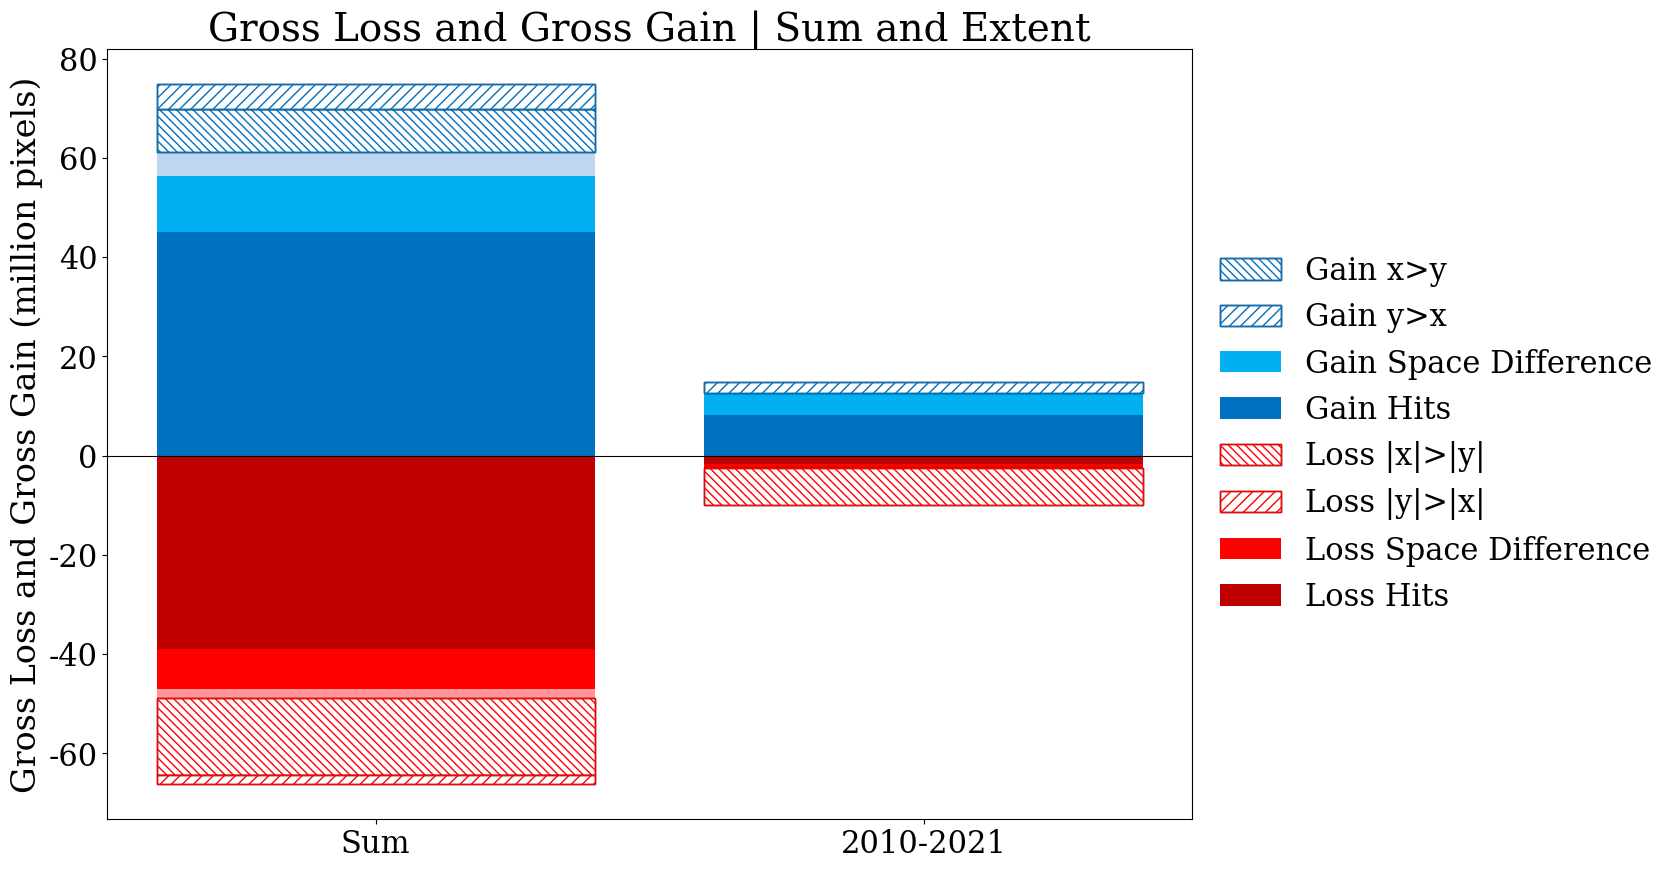

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\gross_change_sum_extent_PIE.png


In [10]:
# =============================================================================
# 7.2 Plot gross change (sum and extent)
# =============================================================================
print("\nBuilding the gross change chart (sum and extent)...")

mpl.rcParams["font.family"] = "serif"

extent_label = f"{time_points[0]}-{time_points[-1]}"

summary_df = (
    gross_df[
        gross_df["Interval"].isin(["Sum", extent_label])
    ]
    .copy()
    .set_index("Interval")
    .fillna(0)
)

labels = summary_df.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Space Difference": "#00B0F0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white",
}
loss_colors = {
    "Hits": "#C00000",
    "Space Difference": "#FF0000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white",
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

fig, ax = plt.subplots(
    figsize=(14, 10)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

bottom_gain = np.zeros(len(labels))

for component in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "x>y"
        if component == "Miss"
        else (
            "y>x"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Gain {component}"
    values = summary_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Gain {display}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Gain {display}",
            color=gain_colors.get(component, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none"
        )

    bottom_gain += values

bottom_loss = np.zeros(len(labels))

for component in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "|x|>|y|"
        if component == "Miss"
        else (
            "|y|>|x|"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Loss {component}"
    values = summary_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Loss {display}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Loss {display}",
            color=loss_colors.get(component, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none"
        )

    bottom_loss += values

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///"
    )
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///"
    )
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Space Difference",
    "Loss Hits",
]

ordered_handles = [
    legend_dict[label]
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=22,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

ax.set_title(
    "Gross Loss and Gross Gain | Sum and Extent",
    fontsize=28
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=22
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=22
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{value / 1_000_000:.0f}"
    )
)
ax.set_ylabel(
    "Gross Loss and Gross Gain (million pixels)",
    fontsize=24
)

output_filename = f"gross_change_sum_extent_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"Chart saved to: {final_chart_path}")

## 8. Plot Net Change

### 8.1 Time Intervals


Building the net change chart (intervals)...


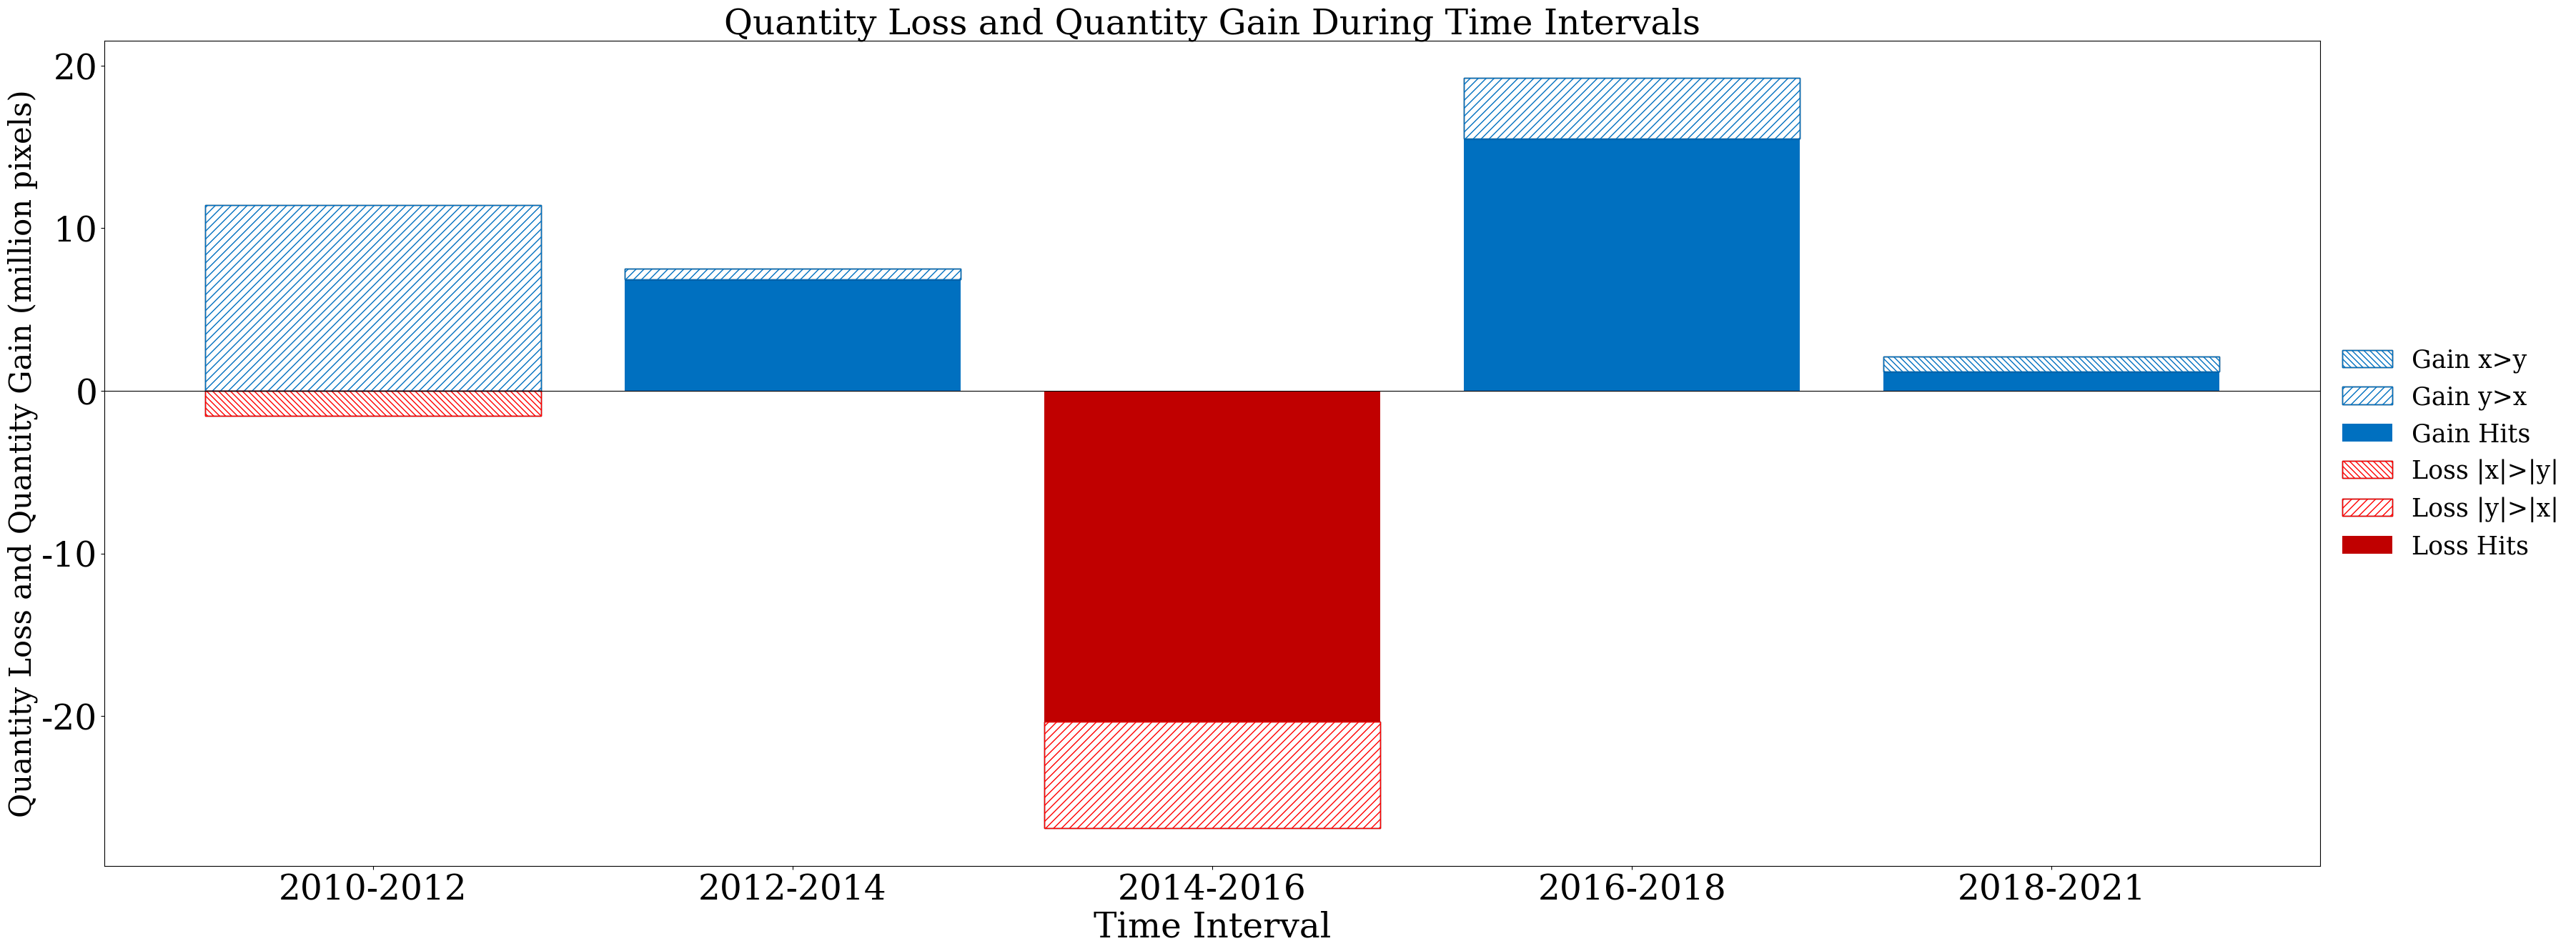

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\net_change_PIE.png


In [11]:
# =============================================================================
# 8.1 Plot net change across time intervals
# =============================================================================
print("\nBuilding the net change chart (intervals)...")

mpl.rcParams["font.family"] = "serif"

extent_label = f"{time_points[0]}-{time_points[-1]}"

net_intervals_df = (
    net_df[
        ~net_df["Interval"].isin(["Sum", extent_label])
    ]
    .copy()
    .fillna(0)
)

labels = net_intervals_df["Interval"].tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white",
}
loss_colors = {
    "Hits": "#C00000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white",
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

bottom_gain = np.zeros(len(labels))

for component in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "x>y"
        if component == "Miss"
        else (
            "y>x"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Gain {component}"
    values = net_intervals_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Gain {display}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Gain {display}",
            color=gain_colors.get(component, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none"
        )

    bottom_gain += values

bottom_loss = np.zeros(len(labels))

for component in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "|x|>|y|"
        if component == "Miss"
        else (
            "|y|>|x|"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Loss {component}"
    values = net_intervals_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Loss {display}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Loss {display}",
            color=loss_colors.get(component, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none"
        )

    bottom_loss += values

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///"
    )
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///"
    )
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Hits",
]

ordered_handles = [
    legend_dict[label]
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

ax.set_title(
    "Quantity Loss and Quantity Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=35
)

def millions_formatter(y_value, _):
    return f"{y_value / 1_000_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)
ax.set_ylabel(
    "Quantity Loss and Quantity Gain (million pixels)",
    fontsize=30
)

output_filename = f"net_change_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"Chart saved to: {final_chart_path}")

### 8.2 Sum and Extent


Building the net change chart (sum and extent)...


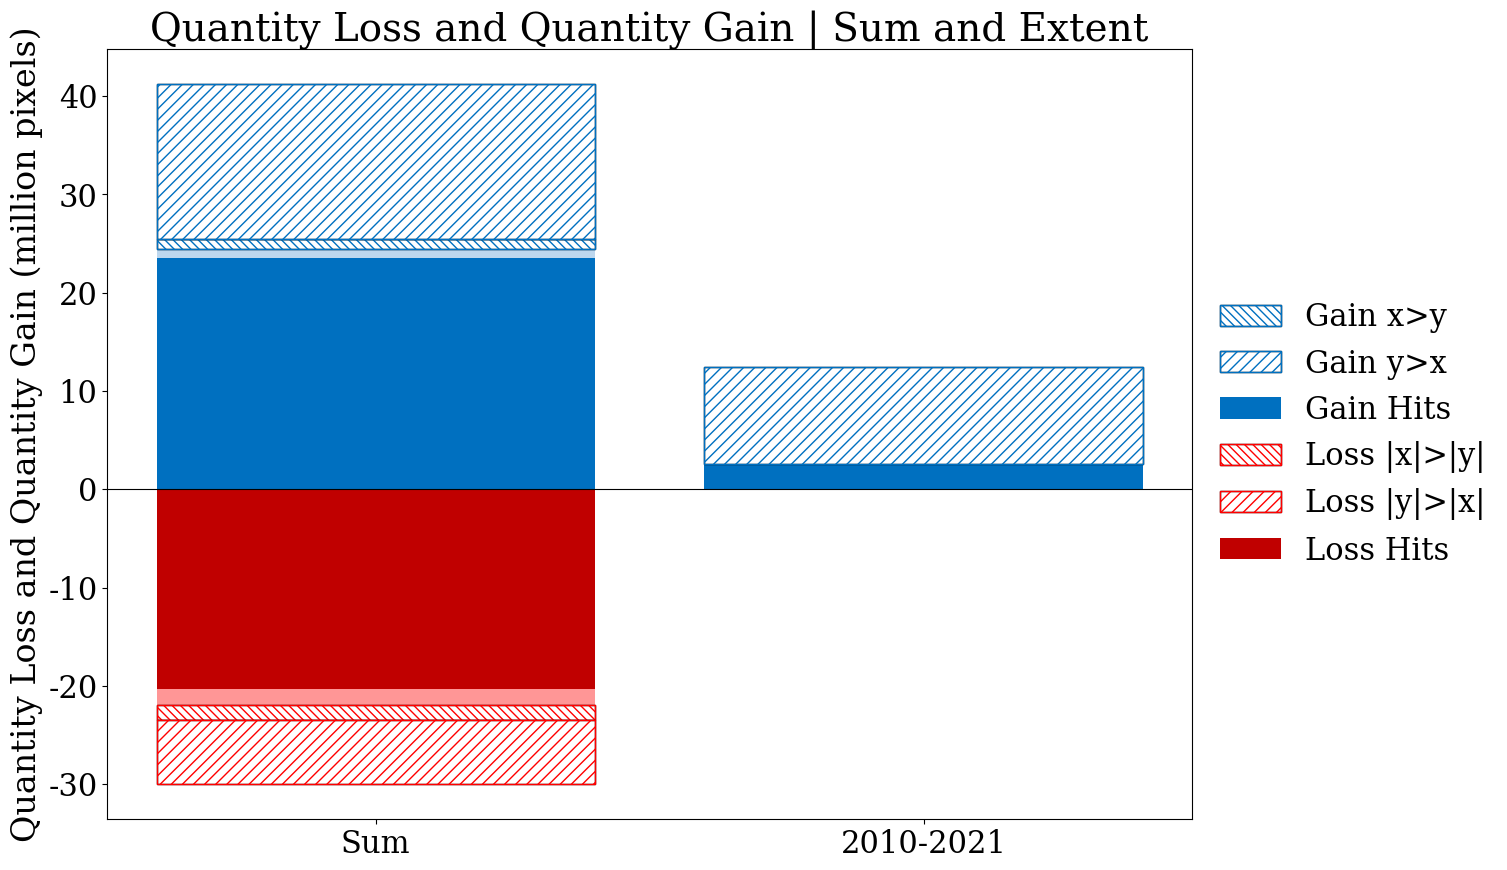

Chart saved to: C:\Users\AntFonseca\github\2.OUTPUT\PIE\net_change_sum_extent_PIE.png


In [12]:
# =============================================================================
# 8.2 Plot net change (sum and extent)
# =============================================================================
print("\nBuilding the net change chart (sum and extent)...")

mpl.rcParams["font.family"] = "serif"

extent_label = f"{time_points[0]}-{time_points[-1]}"

summary_df = (
    net_df[
        net_df["Interval"].isin(["Sum", extent_label])
    ]
    .copy()
    .set_index("Interval")
    .fillna(0)
)

labels = summary_df.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white",
}
loss_colors = {
    "Hits": "#C00000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white",
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

fig, ax = plt.subplots(
    figsize=(14, 10)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

bottom_gain = np.zeros(len(labels))

for component in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "x>y"
        if component == "Miss"
        else (
            "y>x"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Gain {component}"
    values = summary_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Gain {display}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Gain {display}",
            color=gain_colors.get(component, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none"
        )

    bottom_gain += values

bottom_loss = np.zeros(len(labels))

for component in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    display = (
        "|x|>|y|"
        if component == "Miss"
        else (
            "|y|>|x|"
            if component == "False Alarm"
            else component
        )
    )
    column_name = f"Loss {component}"
    values = summary_df[column_name].to_numpy()

    if component in ["Miss", "False Alarm"]:
        plot_values = values.astype(float)
        plot_values[plot_values == 0] = np.nan
        hatch = "///" if component == "False Alarm" else "\\\\\\\\"

        ax.bar(
            labels,
            plot_values,
            label=f"Loss {display}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_values,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            values,
            label=f"Loss {display}",
            color=loss_colors.get(component, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none"
        )

    bottom_loss += values

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=gain_hatch_color,
        hatch="///"
    )
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="\\\\\\\\"
    )
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(
        facecolor="white",
        edgecolor="black"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor=loss_hatch_color,
        hatch="///"
    )
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Hits",
]

ordered_handles = [
    legend_dict[label]
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=22,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

ax.set_title(
    "Quantity Loss and Quantity Gain | Sum and Extent",
    fontsize=28
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=22
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=22
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{value / 1_000_000:.0f}"
    )
)
ax.set_ylabel(
    "Quantity Loss and Quantity Gain (million pixels)",
    fontsize=24
)

output_filename = f"net_change_sum_extent_{class_name}.png"
final_chart_path = output_path / output_filename

plt.savefig(
    final_chart_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"Chart saved to: {final_chart_path}")


## 9. Generate Raster Maps

In [13]:

# =============================================================================
# 9. Generate raster maps
# =============================================================================
print("Starting raster generation...")

reference_profile, raster_height, raster_width = ensure_reference_profile()
profile_template = reference_profile.copy()


def write_raster(data_array, file_name):
    # Persist a float32 raster with LZW compression.
    profile = profile_template.copy()
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw",
        count=1
    )
    raster_path = output_path / file_name
    with rasterio.open(raster_path, "w", **profile) as dst:
        dst.write(
            data_array.astype(np.float32),
            1
        )
    return raster_path


def compute_presence_hit():
    # Compute the presence hit raster across all time points.
    print("\nCalculating Presence Hit raster...")
    accumulator = np.zeros(
        (raster_height, raster_width),
        dtype=np.float32
    )
    final_nodata_mask = np.ones(
        (raster_height, raster_width),
        dtype=bool
    )

    for year in tqdm(time_points, desc="Presence Hit", unit="year"):
        file_name = f"{class_name}{year}.tif"
        path_x = path_series_x / file_name
        path_y = path_series_y / file_name

        if not path_x.exists() or not path_y.exists():
            print(f"Warning: file '{file_name}' not found. Skipping.")
            continue

        with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
            ax = src_x.read(1)
            ay = src_y.read(1)
            mask_x = src_x.read_masks(1) != 0
            mask_y = src_y.read_masks(1) != 0

            valid_mask = (
                mask_x
                & mask_y
                & ~(np.isnan(ax) | np.isnan(ay))
                & (ax != nodata_value)
                & (ay != nodata_value)
            )

            if is_binary_data:
                x_present = ax == 1
                y_present = ay == 1
                hit_map = (x_present & y_present).astype(np.float32)
            else:
                ax_pos = np.maximum(ax.astype(np.float32), 0.0)
                ay_pos = np.maximum(ay.astype(np.float32), 0.0)
                hit_map = np.minimum(ax_pos, ay_pos)

            np.add(
                accumulator,
                hit_map,
                out=accumulator,
                where=valid_mask
            )
            final_nodata_mask &= ~valid_mask

    accumulator[final_nodata_mask] = nodata_value
    raster_path = write_raster(
        accumulator,
        f"presence_hit_{class_name}.tif"
    )
    print(f"Saved: {raster_path}")
    return raster_path


def compute_presence_time_difference():
    # Compute Eq. 51 presence time difference raster.
    print("\nCalculating Presence Time Difference raster (Eq. 51)...")
    cn_map = np.zeros(
        (raster_height, raster_width),
        dtype=np.float32
    )
    prev_nonzero_sign = np.zeros(
        (raster_height, raster_width),
        dtype=np.int8
    )
    final_nodata_mask = np.ones(
        (raster_height, raster_width),
        dtype=bool
    )

    for year in tqdm(time_points, desc="Presence Time Difference", unit="year"):
        file_name = f"{class_name}{year}.tif"
        path_x = path_series_x / file_name
        path_y = path_series_y / file_name

        if not path_x.exists() or not path_y.exists():
            print(f"Warning: file '{file_name}' not found. Skipping.")
            continue

        with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
            ax = src_x.read(1)
            ay = src_y.read(1)
            mask_x = src_x.read_masks(1) != 0
            mask_y = src_y.read_masks(1) != 0

            valid_mask = (
                mask_x
                & mask_y
                & ~(np.isnan(ax) | np.isnan(ay))
                & (ax != nodata_value)
                & (ay != nodata_value)
            )

            if is_binary_data:
                x_present = (ax == 1).astype(np.int8)
                y_present = (ay == 1).astype(np.int8)
                difference = y_present - x_present
            else:
                ax_pos = np.maximum(ax.astype(np.float32), 0.0)
                ay_pos = np.maximum(ay.astype(np.float32), 0.0)
                difference = ay_pos - ax_pos

            sign_curr = np.zeros_like(difference, dtype=np.int8)
            sign_curr[(difference > 0) & valid_mask] = 1
            sign_curr[(difference < 0) & valid_mask] = -1

            changed_mask = (
                (prev_nonzero_sign != 0)
                & (sign_curr != 0)
                & (sign_curr != prev_nonzero_sign)
                & valid_mask
            )

            np.add(
                cn_map,
                1.0,
                out=cn_map,
                where=changed_mask
            )

            prev_nonzero_sign = np.where(
                (sign_curr != 0) & valid_mask,
                sign_curr,
                prev_nonzero_sign
            ).astype(np.int8)

            final_nodata_mask &= ~valid_mask

    cn_map[final_nodata_mask] = nodata_value
    raster_path = write_raster(
        cn_map,
        f"presence_time_difference_{class_name}.tif"
    )
    print(f"Saved: {raster_path}")
    return raster_path

Starting raster generation...



## 10. Visualize Raster Maps

In [14]:

# =============================================================================
# 10. Visualize raster maps
# =============================================================================
print("Preparing map visualizations...")

def plot_presence_hit_map(raster_path):
    # Plot and export the Presence Hit map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    if is_binary_data:
        num_points = len(time_points)
        boundaries = np.arange(-0.5, num_points + 1.5, 1.0)

        viridis = mpl.colormaps["viridis"].resampled(
            max(num_points, 1)
        )
        colors_step = viridis(
            np.linspace(
                0.0,
                1.0,
                num_points,
                endpoint=True
            )
        )
        colors = ["#f2f2f2"] + [
            mcolors.to_hex(color)
            for color in colors_step
        ]
        cmap = ListedColormap(colors)
        cmap.set_bad(color="white")
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        colors = [
            "#f2f2f2",
            "#23b0f1",
            "#026092",
            "#051927"
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "gray_to_blue_hits",
            colors
        )
        cmap.set_bad(color="white")
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        norm = mcolors.Normalize(
            vmin=0.0,
            vmax=max_val
        )

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data:
        legend_labels = [
            str(value)
            for value in range(len(time_points) + 1)
        ]
        patches = [
            mpatches.Patch(
                color=colors[index],
                label=legend_labels[index]
            )
            for index in range(len(legend_labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Sum of Hits",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    else:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.5
        )
        colorbar.set_label(
            "Sum of Hits",
            fontsize=12,
            rotation=0,
            y=1.08,
            labelpad=0
        )
        colorbar.set_ticks(
            np.linspace(
                0.0,
                max_val,
                num=6
            )
        )

    ax.set_title(
        f"Presence Hits - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"presence_hit_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_presence_time_difference_map(raster_path):
    # Plot and export the Presence Time Difference map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    num_points = len(time_points)
    num_intervals = max(0, num_points - 1)
    boundaries = np.arange(-0.5, num_intervals + 1.5, 1.0)

    if num_intervals > 0:
        magma = mpl.colormaps["magma"].resampled(num_intervals)
        colors_step = magma(
            np.linspace(
                0.0,
                1.0,
                num_intervals,
                endpoint=True
            )
        )
        colors = ["#f2f2f2"] + [
            mcolors.to_hex(color)
            for color in colors_step
        ]
    else:
        colors = ["#f2f2f2"]

    cmap = ListedColormap(colors)
    cmap.set_bad(color="white")
    norm = BoundaryNorm(boundaries, cmap.N)

    ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    legend_labels = [
        str(value)
        for value in range(num_intervals + 1)
    ]
    patches = [
        mpatches.Patch(
            color=colors[index],
            label=legend_labels[index]
        )
        for index in range(len(legend_labels))
    ]
    legend = ax.legend(
        handles=patches,
        title="Time Difference",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for item in legend.get_texts():
        item.set_ha("left")

    ax.set_title(
        f"Presence Time Difference - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"presence_temporal_disagreement_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_presence_difference_map(raster_path):
    # Plot and export the Presence Difference map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    if is_binary_data:
        if masked_map.count() > 0:
            min_val = int(np.floor(np.ma.min(masked_map)))
            max_val = int(np.ceil(np.ma.max(masked_map)))
        else:
            min_val, max_val = -1, 1

        if min_val < 0 and max_val > 0:
            sym = max(abs(min_val), abs(max_val))
            min_val = -sym
            max_val = sym

        colors_for_legend = []
        labels_for_legend = []

        if min_val < 0:
            neg_steps = abs(min_val)
            red_cmap = plt.get_cmap("Reds_r", max(neg_steps, 1))
            for index in range(neg_steps):
                fraction = 0.0 if neg_steps == 1 else index / (neg_steps - 1)
                colors_for_legend.append(
                    mcolors.to_hex(red_cmap(fraction))
                )
            labels_for_legend.extend(range(min_val, 0))

        if min_val <= 0 <= max_val:
            colors_for_legend.append("#f2f2f2")
            labels_for_legend.append(0)

        if max_val > 0:
            pos_steps = max_val
            blue_cmap = plt.get_cmap("Blues", max(pos_steps, 1))
            for index in range(pos_steps):
                fraction = 0.0 if pos_steps == 1 else index / (pos_steps - 1)
                colors_for_legend.append(
                    mcolors.to_hex(blue_cmap(fraction))
                )
            labels_for_legend.extend(range(1, max_val + 1))

        cmap = ListedColormap(colors_for_legend)
        cmap.set_bad(color="white")
        boundaries = np.arange(min_val - 0.5, max_val + 1.5, 1.0)
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        vmin = float(np.ma.min(masked_map)) if masked_map.count() > 0 else -1.0
        vmax = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        amax = max(abs(vmin), abs(vmax))
        norm = mcolors.Normalize(
            vmin=-amax,
            vmax=amax
        )
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "diff_diverging",
            [
                "#f4a582",
                "#d6604d",
                "#b2182b",
                "#f2f2f2",
                "#2166ac",
                "#4393c3",
                "#92c5de"
            ]
        )
        cmap.set_bad(color="white")

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data:
        patches = [
            mpatches.Patch(color=color, label=str(label))
            for color, label in zip(colors_for_legend, labels_for_legend)
        ]
        patches.reverse()
        legend = ax.legend(
            handles=patches,
            title="Difference",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    else:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.7
        )
        colorbar.set_label(
            "Presence Difference",
            fontsize=12,
            rotation=270,
            labelpad=20
        )

    ax.set_title(
        f"Presence Difference - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"presence_difference_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_presence_absolute_difference_map(raster_path):
    # Plot and export the Presence Absolute Difference map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    legend_colors = []
    legend_labels = []

    if is_binary_data:
        unique_vals = (
            sorted(np.unique(masked_map.compressed()).astype(int))
            if masked_map.count() > 0 else [0]
        )
        blue_cmap = plt.get_cmap("Blues")

        if 0 in unique_vals:
            legend_colors.append("#f2f2f2")
            legend_labels.append("0")

        positive_vals = [value for value in unique_vals if value > 0]
        count_pos = len(positive_vals)

        if count_pos > 0:
            blue_shades = [
                blue_cmap(fraction)
                for fraction in np.linspace(0.35, 1.0, count_pos)
            ]
            legend_colors.extend(
                [mcolors.to_hex(color) for color in blue_shades]
            )
            legend_labels.extend([str(value) for value in positive_vals])

        cmap = ListedColormap(
            legend_colors if legend_colors else ["#f2f2f2"]
        )
        cmap.set_bad(color="white")

        if unique_vals:
            boundaries = [value - 0.5 for value in unique_vals] + [unique_vals[-1] + 0.5]
        else:
            boundaries = [-0.5, 0.5]
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "gray_to_blue_abs",
            [
                "#f2f2f2",
                plt.get_cmap("Blues")(1.0)
            ]
        )
        cmap.set_bad(color="white")
        norm = mcolors.Normalize(
            vmin=0.0,
            vmax=max_val
        )

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data and legend_labels:
        patches = [
            mpatches.Patch(
                color=legend_colors[index],
                label=legend_labels[index]
            )
            for index in range(len(legend_labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Absolute Difference",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    elif not is_binary_data:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.7
        )
        colorbar.set_label(
            "Absolute Difference",
            fontsize=12,
            rotation=270,
            labelpad=20
        )
        colorbar.set_ticks(
            np.linspace(0.0, max_val, num=6)
        )

    ax.set_title(
        f"Presence Absolute Difference - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"presence_absolute_difference_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_change_hit_map(raster_path):
    # Plot and export the Change Hit map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    if is_binary_data:
        num_intervals = max(0, len(time_points) - 1)
        boundaries = np.arange(-0.5, num_intervals + 1.5, 1.0)

        base = mpl.colormaps["RdYlBu"]
        if num_intervals > 0:
            samples = np.linspace(0.0, 1.0, num_intervals, endpoint=True)
            interval_colors = [
                mcolors.to_hex(base(sample))
                for sample in samples
            ]
        else:
            interval_colors = []
        colors = ["#f2f2f2"] + interval_colors

        cmap = ListedColormap(colors)
        cmap.set_bad(color="white")
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        base = mpl.colormaps["RdYlBu"]
        colors = ["#f2f2f2"] + [
            mcolors.to_hex(base(sample))
            for sample in np.linspace(0.0, 1.0, 256)
        ]
        cmap = ListedColormap(colors)
        cmap.set_bad(color="white")
        norm = mcolors.Normalize(
            vmin=0.0,
            vmax=max_val
        )

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data:
        legend_labels = [
            str(value)
            for value in range(num_intervals + 1)
        ]
        patches = [
            mpatches.Patch(
                color=colors[index],
                label=legend_labels[index]
            )
            for index in range(len(legend_labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Change Hits",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    else:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.5
        )
        colorbar.set_label(
            "Change Hits",
            fontsize=12,
            rotation=270,
            labelpad=20
        )
        colorbar.set_ticks(
            np.linspace(
                0.0,
                max_val,
                num=6
            )
        )

    ax.set_title(
        f"Change Hits - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"change_hit_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path
def plot_change_difference_map(raster_path):
    # Plot and export the Change Difference map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    base_cmap = blue_gray_red_cmap()

    if is_binary_data:
        if masked_map.count() > 0:
            vmin = int(np.floor(np.ma.min(masked_map)))
            vmax = int(np.ceil(np.ma.max(masked_map)))
        else:
            vmin, vmax = -1, 1
        sym = max(abs(vmin), abs(vmax))
        values = list(range(-sym, sym + 1))
        colors = [
            "#f2f2f2" if value == 0 else mcolors.to_hex(base_cmap((value + sym) / (2 * sym)))
            for value in values
        ]
        cmap = ListedColormap(colors)
        cmap.set_bad(color="white")
        boundaries = np.arange(-sym - 0.5, sym + 1.5, 1.0)
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        vmin = float(np.ma.min(masked_map)) if masked_map.count() > 0 else -1.0
        vmax = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        amax = max(abs(vmin), abs(vmax))
        norm = mcolors.Normalize(
            vmin=-amax,
            vmax=amax
        )
        cmap = base_cmap
        cmap.set_bad(color="white")

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data:
        values_desc = list(range(sym, -sym - 1, -1))
        patches = [
            mpatches.Patch(
                color=mcolors.to_hex(cmap(norm(value))),
                label=str(value)
            )
            for value in values_desc
        ]
        legend = ax.legend(
            handles=patches,
            title="Change Difference",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    else:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.7
        )
        colorbar.set_label(
            "Change Difference",
            fontsize=12,
            rotation=270,
            labelpad=20
        )
        colorbar.set_ticks(
            np.linspace(-amax, amax, num=7)
        )

    ax.set_title(
        f"Change Difference - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"change_difference_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_change_absolute_difference_map(raster_path):
    # Plot and export the Change Absolute Difference map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    legend_colors = []
    legend_labels = []

    if is_binary_data:
        unique_vals = (
            sorted(np.unique(masked_map.compressed()).astype(int))
            if masked_map.count() > 0 else [0]
        )
        blue_cmap = plt.get_cmap("Blues")

        if 0 in unique_vals:
            legend_colors.append("#f2f2f2")
            legend_labels.append("0")

        positive_vals = [value for value in unique_vals if value > 0]
        count_pos = len(positive_vals)

        if count_pos > 0:
            blue_shades = [
                blue_cmap(fraction)
                for fraction in np.linspace(0.35, 1.0, count_pos)
            ]
            legend_colors.extend(
                [mcolors.to_hex(color) for color in blue_shades]
            )
            legend_labels.extend([str(value) for value in positive_vals])

        cmap = ListedColormap(
            legend_colors if legend_colors else ["#f2f2f2"]
        )
        cmap.set_bad(color="white")

        if unique_vals:
            boundaries = [value - 0.5 for value in unique_vals] + [unique_vals[-1] + 0.5]
        else:
            boundaries = [-0.5, 0.5]
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "gray_to_blue_abs",
            [
                "#f2f2f2",
                plt.get_cmap("Blues")(1.0)
            ]
        )
        cmap.set_bad(color="white")
        norm = mcolors.Normalize(
            vmin=0.0,
            vmax=max_val
        )

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data and legend_labels:
        patches = [
            mpatches.Patch(
                color=legend_colors[index],
                label=legend_labels[index]
            )
            for index in range(len(legend_labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Absolute Difference",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    elif not is_binary_data:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.7
        )
        colorbar.set_label(
            "Absolute Difference",
            fontsize=12,
            rotation=270,
            labelpad=20
        )
        colorbar.set_ticks(
            np.linspace(0.0, max_val, num=6)
        )

    ax.set_title(
        f"Change Absolute Difference - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"change_absolute_difference_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path
def plot_change_difference_sign_v10_map(raster_path):
    # Plot and export the Change Difference (Eₙ, Eq. 53 v10) map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    if masked_map.count() > 0:
        min_obs = int(np.floor(np.ma.min(masked_map)))
        max_obs = int(np.ceil(np.ma.max(masked_map)))
    else:
        min_obs, max_obs = 0, 0

    lo = min(min_obs, -2)
    hi = max(max_obs, 2)
    if lo > 0:
        lo = 0
    if hi < 0:
        hi = 0

    boundaries = np.arange(lo - 0.5, hi + 1.5, 1.0)
    n_classes = len(boundaries) - 1

    base = blue_gray_red_cmap()
    colors = [
        mcolors.to_hex(color)
        for color in base(
            np.linspace(0.0, 1.0, n_classes, endpoint=True)
        )
    ]

    zero_index = -lo if lo <= 0 <= hi else None
    if zero_index is not None and 0 <= zero_index < len(colors):
        colors[zero_index] = "#f2f2f2"

    cmap = ListedColormap(colors)
    cmap.set_bad(color="white")
    norm = BoundaryNorm(boundaries, cmap.N)

    ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    class_values_desc = list(range(hi, lo - 1, -1))
    patches = []
    for value in class_values_desc:
        index = value - lo
        color = colors[index]
        patches.append(
            mpatches.Patch(
                color=color,
                label=str(value)
            )
        )

    legend = ax.legend(
        handles=patches,
        title="Change Difference (Eₙ)",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for item in legend.get_texts():
        item.set_ha("left")

    ax.set_title(
        f"Change Difference (Eₙ, Eq. 53 v10) - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"change_difference_sign_v10_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


def plot_change_absolute_difference_sign_v10_map(raster_path):
    # Plot and export the Change Absolute Difference (Fₙ, Eq. 54 v10) map.
    masked_map, bounds, src_crs, transformer = read_resampled_map(raster_path)
    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    legend_colors = []
    legend_labels = []

    if is_binary_data:
        unique_vals = (
            sorted(np.unique(masked_map.compressed()).astype(int))
            if masked_map.count() > 0 else [0]
        )
        blue_cmap = plt.get_cmap("Blues")

        if 0 in unique_vals:
            legend_colors.append("#f2f2f2")
            legend_labels.append("0")

        positive_vals = [value for value in unique_vals if value > 0]
        count_pos = len(positive_vals)

        if count_pos > 0:
            blue_shades = [
                blue_cmap(fraction)
                for fraction in np.linspace(0.35, 1.0, count_pos)
            ]
            legend_colors.extend(
                [mcolors.to_hex(color) for color in blue_shades]
            )
            legend_labels.extend([str(value) for value in positive_vals])

        cmap = ListedColormap(
            legend_colors if legend_colors else ["#f2f2f2"]
        )
        cmap.set_bad(color="white")

        if unique_vals:
            boundaries = [value - 0.5 for value in unique_vals] + [unique_vals[-1] + 0.5]
        else:
            boundaries = [-0.5, 0.5]
        norm = BoundaryNorm(boundaries, cmap.N)
    else:
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "gray_to_blue_abs",
            [
                "#f2f2f2",
                plt.get_cmap("Blues")(1.0)
            ]
        )
        cmap.set_bad(color="white")
        norm = mcolors.Normalize(
            vmin=0.0,
            vmax=max_val
        )

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]
    )

    prepare_map_axes(
        ax,
        bounds,
        src_crs,
        transformer
    )

    if is_binary_data and legend_labels:
        patches = [
            mpatches.Patch(
                color=legend_colors[index],
                label=legend_labels[index]
            )
            for index in range(len(legend_labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Absolute Difference (Fₙ)",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for item in legend.get_texts():
            item.set_ha("left")
    elif not is_binary_data:
        colorbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.08,
            shrink=0.7
        )
        colorbar.set_label(
            "Absolute Difference (Fₙ)",
            fontsize=12,
            rotation=270,
            labelpad=20
        )
        max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
        ticks = np.linspace(0.0, max_val, num=min(6, int(max_val) + 1))
        colorbar.set_ticks(ticks)
        colorbar.set_ticklabels([str(int(value)) for value in ticks])

    ax.set_title(
        f"Change Absolute Difference (Fₙ, Eq. 54 v10) - {class_name.capitalize()}",
        fontsize=18,
        pad=20
    )

    png_path = output_path / f"change_absolute_difference_sign_v10_{class_name}_map.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return png_path


map_pngs = {}

map_pngs["presence_hit"] = plot_presence_hit_map(
    raster_outputs["presence_hit"]
)
map_pngs["presence_time_difference"] = plot_presence_time_difference_map(
    raster_outputs["presence_time_difference"]
)
map_pngs["presence_difference"] = plot_presence_difference_map(
    raster_outputs["presence_difference"]
)
map_pngs["presence_absolute_difference"] = plot_presence_absolute_difference_map(
    raster_outputs["presence_absolute_difference"]
)
map_pngs["change_hit"] = plot_change_hit_map(
    raster_outputs["change_hit"]
)
map_pngs["change_difference"] = plot_change_difference_map(
    raster_outputs["change_difference"]
)
map_pngs["change_absolute_difference"] = plot_change_absolute_difference_map(
    raster_outputs["change_absolute_difference"]
)
map_pngs["change_difference_sign_v10"] = plot_change_difference_sign_v10_map(
    raster_outputs["change_difference_sign_v10"]
)
map_pngs["change_absolute_difference_sign_v10"] = plot_change_absolute_difference_sign_v10_map(
    raster_outputs["change_absolute_difference_sign_v10"]
)

print("\nMap exports completed.")
for name, path in map_pngs.items():
    print(f" - {name}: {path}")

Preparing map visualizations...


NameError: name 'raster_outputs' is not defined